# Tarea 3: Multi-Layer Perceptrons (MLPs) 

Código por: Mair Escobar

https://github.com/MaiR42/TAREAS_IA_2026-01/tree/main/Tarea3


### Declaración de IA:

* Se utilizo IA significativamente en las siguientes partes:

    * Cargar la información de los datasets y eliminar filas con valores faltantes

    * Aproximar valores para construir la MLP (número de capas ocultas y cantidad de neuronas para elegir una número lógico de utilizar)
    * Principalmente poder decidir que valores utilizar para redes más simples o profundas.
    * Definir valores de random_state, early_stopping, validation_fraction, n_iter_no_change

    * Estructurar funciones

    * Construcción de la matriz de confusión

    * Parámetros y funciones relacionadas a la función de evaluación de modelos (métricas)

    * Graficar las curvas de entrenamiento y validación por época de los modelos

    * Mostrar comparación entre arquitecturas


In [1]:
!pip install --upgrade pandas numpy scikit-learn matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

SEED = 42 # Para no obtener resultados random cada vez que pruebo entrenamiento, validacion y test

## Item 0) Cargar Datasets

* Cosas que se consideraron: 
    * postures_balanced_50000 tiene valores faltantes en algunas variables y todas son continuas a excepcion de (Class,User)
    * postures_imbalanced_50000 tiene valores faltantes en algunas variables y todas son continuas a excepcion de (Class,User)

    * También hay variables con valores negativos

* Se decidió borrar filas con datos faltantes


In [3]:
def load_dataset(path):
    df = pd.read_csv(path)
    nombre = os.path.splitext(os.path.basename(path))[0] # DELETE, solo para despues hacer el grafico
 
    print(f"\n{'='*55}")
    print(f"Dataset: {nombre}")
    print(f"  Shape original   : {df.shape}")
    df = df.dropna() # Borrar filas con datos faltantes
    print(f"  Shape despues de borrar filas con datos faltantes: {df.shape}")

    # Para ver la distribucion de datos segun la variable "Class"
    print(f"  Distribución de clases:\n{df['Class'].value_counts().sort_index().to_string()}") 
 
    # Borrar Class y User de features
    feature_cols = [c for c in df.columns if c not in ("Class", "User")]
    X = df[feature_cols].values.astype(np.float64)
    y = df["Class"].values.astype(int)
 
    return X, y, nombre

X_balanced, y_balanced, nombre_b = load_dataset("datasets/postures_balanced_50000.csv") # DELETE NOMBRE_B
X_imbalanced, y_imbalanced, nombre_imb = load_dataset("datasets/postures_imbalanced_50000.csv") # DELETE NOMBRE_IMB


Dataset: postures_balanced_50000
  Shape original   : (50000, 23)
  Shape despues de borrar filas con datos faltantes: (34131, 23)
  Distribución de clases:
Class
1    1669
2    9845
3    3989
4    8837
5    9791

Dataset: postures_imbalanced_50000
  Shape original   : (50000, 23)
  Shape despues de borrar filas con datos faltantes: (26829, 23)
  Distribución de clases:
Class
1     2591
2    13804
3     5914
4     3537
5      983


## Ítem 1)


### Separar datos para utilizar en entrenamiento, validación y prueba

In [4]:
def split_data(X, y):
    # Primero separar test (15%)
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, random_state=SEED, stratify=y
    )
    # Del resto, separar val (15% del total = 15/85 del restante)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=(0.15 / 0.85), random_state=SEED, stratify=y_temp
    )
    print(f"  Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}")
    return X_train, X_val, X_test, y_train, y_val, y_test

X_b_train,   X_b_val,   X_b_test,   y_b_train,   y_b_val,   y_b_test   = split_data(X_balanced,   y_balanced)
X_imb_train, X_imb_val, X_imb_test, y_imb_train, y_imb_val, y_imb_test = split_data(X_imbalanced, y_imbalanced)

  Train: 23891 | Val: 5120 | Test: 5120
  Train: 18779 | Val: 4025 | Test: 4025


### Realizar escalado para el conjunto de datos de entrenamiento

In [5]:
def scale_data(X_train, X_val, X_test):
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)
    return X_train, X_val, X_test

X_b_train,   X_b_val,   X_b_test   = scale_data(X_b_train,   X_b_val,   X_b_test)
X_imb_train, X_imb_val, X_imb_test = scale_data(X_imb_train, X_imb_val, X_imb_test)

### Definir arquitecturas MLP a entrenar

Se utilizo el optimizador de "adam" (por defecto en MLP), ya que era el que tenia una convergencia más rápida, además de ser eficiente.

1) idea: Red simple. Con pocas capas y neuronas
    * con 2 capas ocultas de 64 y 32 neuronas respectivamente. Para probar una red poco profunda con pocas neuronas para encontrar relaciones simples.
    * con función de activación "relu". Rápida de entrenar.
    * batch-size de 128. Valor moderado para ser estable y rápido.
    * learning rate y regularización (alpha) con valores default. Valores estándar para que la red ajuste sus pesos.
    * Numero de épocas 100.

2) idea: Red profunda. Mayor cantidad de capas y cambios en el resto de parámetros (Para comparar con arquitectura 1)
    * con 3 capas ocultas de 64, 32 y 16 neuronas respectivamente. Para probar una red más profunda, al tener 3 capas ocultas permite encontrar más relaciones entre las features. 
    * con función de activación "relu".
    * batch-size de 256. Valor más alto para que los datos utilizados para ajustar pesos sean más estables.
    * learning rate más bajo y regularización (alpha) más alta. Dado que la complejidad de la red es mayor el modelo puede tender a tener mayor overfitting, por lo que se penaliza de manera más fuerte a las variables.
    * Numero de épocas 100.

3) Idea: Red pequeña, pero con mayor cantidad de neuronas por capa y utilizando Tangente Hiperbólica en vez de ReLU.
    * con 2 capas ocultas de 256 y 128 neuronas respectivamente.
    * con función de activación "tanh".
    * batch-size de 512. Hace actualizaciones más estables
    * learning rate y regularización (alpha) con valores default. Valores estándar para que la red ajuste sus pesos.
    * Numero de épocas 100.

4) Idea: Red profunda con mayor cantidad de capas y utilizando función de activación Sigmoide.
    * con 4 capas ocultas de 256, 128, 64 y 32 neuronas respectivamente.
    * con función de activación "logistic".
    * batch-size de 512. Hace actualizaciones más estables
    * learning rate con valor default y regularización (alpha) fuerte. Para castigar de manera más severa el overfitting.
    * Numero de épocas 150.


In [ ]:
def get_arquitecturas():
    return {
        "A1": MLPClassifier(
            hidden_layer_sizes  = (64, 32),
            activation          = "relu",
            learning_rate_init  = 0.001, # Valor por default
            batch_size          = 128,
            max_iter            = 100,
            alpha               = 0.0001, # Valor por default
            random_state        = SEED,
            early_stopping      = True,
            validation_fraction = 0.1,
            n_iter_no_change    = 15,
        ),
        "A2": MLPClassifier(
            hidden_layer_sizes  = (64, 32, 16),
            activation          = "relu",
            learning_rate_init  = 0.001,
            batch_size          = 128,
            max_iter            = 100,
            alpha               = 0.0001,
            random_state        = SEED,
            early_stopping      = True,
            validation_fraction = 0.1,
            n_iter_no_change    = 15,
        ),
        "A3": MLPClassifier(
            hidden_layer_sizes  = (256, 128),
            activation          = "tanh",
            learning_rate_init  = 0.001,
            batch_size          = 512,  # Actualizaciones más estables
            max_iter            = 100,
            alpha               = 0.0001,
            random_state        = SEED,
            early_stopping      = True,
            validation_fraction = 0.1,
            n_iter_no_change    = 15,
        ),
        "A4": MLPClassifier(
            hidden_layer_sizes  = (256, 128, 64, 32),
            activation          = "logistic",
            learning_rate_init  = 0.001,
            batch_size          = 512, # Actualizaciones más estables
            max_iter            = 150,
            alpha               = 0.01, # Castigo fuerte para variables, más overfitting
            random_state        = SEED,
            early_stopping      = True,
            validation_fraction = 0.1,
            n_iter_no_change    = 15,
        ),
    }



### Entrenamiento

In [7]:
def entrenar(X_train, X_val, X_test, y_train, y_val, y_test): # Para entrenar todos los modelos a la vez
    arquitecturas = get_arquitecturas()
    resultados = {}

    for nombre_arq, modelo in arquitecturas.items(): 
        print(f"\n  ===== {nombre_arq} =====")
        modelo.fit(X_train, y_train)

        acc_train = accuracy_score(y_train, modelo.predict(X_train))
        acc_val   = accuracy_score(y_val,   modelo.predict(X_val))
        acc_test  = accuracy_score(y_test,  modelo.predict(X_test))

        print(f"     Épocas   : {modelo.n_iter_}")
        print(f"     Acc Train: {acc_train:.4f}")
        print(f"     Acc Val  : {acc_val:.4f}")
        print(f"     Acc Test : {acc_test:.4f}")

        resultados[nombre_arq] = {
            "modelo":    modelo,
            "acc_train": acc_train,
            "acc_val":   acc_val,
            "acc_test":  acc_test,
            "epocas":    modelo.n_iter_,
        }

    return resultados

In [8]:
print("\n--- Entrenando: BALANCED ---")
resultados_b = entrenar(X_b_train, X_b_val, X_b_test, y_b_train, y_b_val, y_b_test)


--- Entrenando: BALANCED ---

  ===== A1 =====
     Épocas   : 100
     Acc Train: 0.9701
     Acc Val  : 0.9303
     Acc Test : 0.9336

  ===== A2 =====
     Épocas   : 76
     Acc Train: 0.9668
     Acc Val  : 0.9314
     Acc Test : 0.9256

  ===== A3 =====
     Épocas   : 75
     Acc Train: 0.9863
     Acc Val  : 0.9424
     Acc Test : 0.9465

  ===== A4 =====
     Épocas   : 150
     Acc Train: 0.9425
     Acc Val  : 0.9176
     Acc Test : 0.9129


In [9]:

print("\n--- Entrenando: IMBALANCED ---")
resultados_imb = entrenar(X_imb_train, X_imb_val, X_imb_test, y_imb_train, y_imb_val, y_imb_test)


--- Entrenando: IMBALANCED ---

  ===== A1 =====
     Épocas   : 83
     Acc Train: 0.9645
     Acc Val  : 0.9250
     Acc Test : 0.9222

  ===== A2 =====
     Épocas   : 81
     Acc Train: 0.9713
     Acc Val  : 0.9242
     Acc Test : 0.9265

  ===== A3 =====
     Épocas   : 91
     Acc Train: 0.9729
     Acc Val  : 0.9406
     Acc Test : 0.9299

  ===== A4 =====
     Épocas   : 62
     Acc Train: 0.8414
     Acc Val  : 0.8425
     Acc Test : 0.8298


## Item 2)

In [10]:
X_b_train,   X_b_val,   X_b_test,   y_b_train,   y_b_val,   y_b_test   = split_data(X_balanced,   y_balanced)
X_imb_train, X_imb_val, X_imb_test, y_imb_train, y_imb_val, y_imb_test = split_data(X_imbalanced, y_imbalanced)

X_b_train,   X_b_val,   X_b_test   = scale_data(X_b_train,   X_b_val,   X_b_test)
X_imb_train, X_imb_val, X_imb_test = scale_data(X_imb_train, X_imb_val, X_imb_test)

  Train: 23891 | Val: 5120 | Test: 5120
  Train: 18779 | Val: 4025 | Test: 4025


### Definir mejor arquitectura para cada dataset

* En este caso la mejor arquitectura para ambos datasets fue la A3, que utilizaba pocas capas con más neuronas y función de activación Tangente Hiperbólica

* Ya que consiguió el mejor accuracy en validación entre los demás modelos. (BALANCED A3 Acc Val  : 0.9424  ;  IMBALANCED A3 Acc Val  : 0.9406)


In [11]:
def mejor_arquitectura():
    return MLPClassifier(
            hidden_layer_sizes  = (256, 128),
            activation          = "tanh",
            learning_rate_init  = 0.001,
            batch_size          = 512,  # Actualizaciones más estables
            max_iter            = 100,
            alpha               = 0.0001,
            random_state        = SEED,
            early_stopping      = True,
            validation_fraction = 0.1,
            n_iter_no_change    = 15,
        )

In [12]:
modelo_b = mejor_arquitectura()
modelo_b.fit(X_b_train, y_b_train)
 
modelo_imb = mejor_arquitectura()
modelo_imb.fit(X_imb_train, y_imb_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(256, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",512
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"n_iter_no_change n_iter_no_change: int, default=10Maximum number of epochs to not meet ``tol`` improvement.Only effective when solver='sgd' or 'adam'... versionadded:: 0.20",15
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 

### Función para evaluación de los modelos

Métricas

* Accuracy: Es la exactitud con la que el modelo acierta la clase correcta.
* Precision: Permite evaluar la confiabilidad de la predicción del modelo (Cuantas veces acertó correctamente la predicción).
* Recall: Permite evaluar la cantidad real de falsos negativos (Cuantas veces el modelo eligió incorrectamente la clase).
* F1: Métrica para evaluar estabilidad del modelo (se basa en accuracy y precision).
* Matriz de confusión: Permite ver que clases se están confundiendo entre sí.


In [13]:
def evaluar_modelo(modelo, X_test, y_test, nombre_ds):
    y_pred = modelo.predict(X_test)
 
    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall    = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1        = f1_score(y_test, y_pred, average="macro", zero_division=0)
 
    print(f"========= Evaluacion del dataset {nombre_ds} =========")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {precision:.4f}  (macro)")
    print(f"  Recall    : {recall:.4f}  (macro)")
    print(f"  F1        : {f1:.4f}  (macro)")
    print(f"\n  Reporte por clase:")
    print(classification_report(y_test, y_pred, zero_division=0))
 
    return y_pred, {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}
 
y_b_pred,   metricas_b   = evaluar_modelo(modelo_b,   X_b_test,   y_b_test,   nombre_b)
y_imb_pred, metricas_imb = evaluar_modelo(modelo_imb, X_imb_test, y_imb_test, nombre_imb)

========= Evaluacion del dataset postures_balanced_50000 =========
  Accuracy  : 0.9465
  Precision : 0.9448  (macro)
  Recall    : 0.9493  (macro)
  F1        : 0.9470  (macro)

  Reporte por clase:
              precision    recall  f1-score   support

           1       0.96      0.98      0.97       250
           2       0.95      0.94      0.94      1477
           3       0.91      0.92      0.92       598
           4       0.94      0.94      0.94      1326
           5       0.97      0.97      0.97      1469

    accuracy                           0.95      5120
   macro avg       0.94      0.95      0.95      5120
weighted avg       0.95      0.95      0.95      5120

========= Evaluacion del dataset postures_imbalanced_50000 =========
  Accuracy  : 0.9299
  Precision : 0.9150  (macro)
  Recall    : 0.8811  (macro)
  F1        : 0.8965  (macro)

  Reporte por clase:
              precision    recall  f1-score   support

           1       0.99      0.97      0.98       389


### Matriz de confusion (grafico)

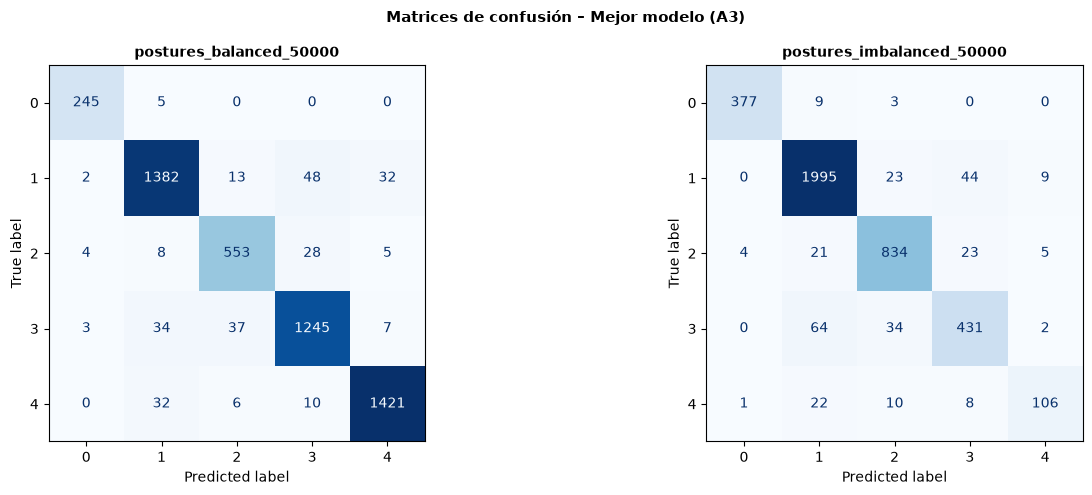

In [14]:
def plot_confusion_matrices(y_b_test, y_b_pred, y_imb_test, y_imb_pred, nombre_b, nombre_imb):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
    for ax, y_test, y_pred, nombre in zip(
        axes,
        [y_b_test,   y_imb_test],
        [y_b_pred,   y_imb_pred],
        [nombre_b,   nombre_imb]
    ):
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(nombre, fontsize=10, fontweight="bold")
 
    fig.suptitle("Matrices de confusión – Mejor modelo (A3)", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()
 
plot_confusion_matrices(y_b_test, y_b_pred, y_imb_test, y_imb_pred, nombre_b, nombre_imb)

### Comparacion de metricas


In [ ]:

print("=========================================")
print(f" METRICA        BALANCED   IMBALANCED")
print("=========================================")
for metrica in ["accuracy", "precision", "recall", "f1"]:
    print(f"  {metrica:<12} {metricas_b[metrica]:>10.4f}  {metricas_imb[metrica]:>10.4f}")

 METRICA        BANLANCED   IMBANLANCED
  accuracy         0.9465      0.9299
  precision        0.9448      0.9150
  recall           0.9493      0.8811
  f1               0.9470      0.8965


#### Análisis de la comparación de evaluación
En general el dataset con datos mejor distribuidos (BALANCED) tuvo mejores resultados.

* Análisis de matriz de confusión:
    * Primero se observa que los cuadros más azules son los que albergan la mayor cantidad de datos. 

    * En el caso de BALANCED se observa que no todas las clases tienen la misma cantidad de datos en el test, esto ya que al principio se eliminaron las filas con valores faltantes. Lo que termino afectando principalmente a la clase 1 y 3 (label 0 y 2).

    *  En BALANCED el modelo tiende a confundir bastante las clases 3, 4 y 5, principalmente con las clases 3, 2, 2 respectivamente; Siendo que solo acierta aproximadamente el 98%, 86%, 78%, 83% y 89% para cada clase. Siendo la clase 3 la más propensa a confundir con otra clase.

    * En IMBALANCE el modelo confunde las clases 3, 4 y 5, principalmente con las clases (2 y 4), 2 y 2 respectivamente; Acertando el 97%, 96%, 94%, 81% y 72% para cada clase. Siendo la clase 5 bastante propensa a confundirse con otra clase. Se observa que el modelo tiende a elegir bastante la clase 2, esto se puede deber a que es la clase con más muestras.


Análisis de la comparación:
* BALANCED
    * Se observan valores más parejos, todos en 0.94, lo que esencialmente indica que el modelo generaliza (busca patrones) con muy buenos resultados. 
    * ~5.5% de que el modelo prediga una clase errónea dado un conjunto de coordenadas.
    * ~5% de que el modelo prediga una clase errónea dado que fallo al detectar la real.

    * Grafico de matriz de confusión: Se observa que las clases que más se confunden son la 3, 4 y 5, con probabilidad de equivocarse mayor al 10%.

* IMBALANCED
    * Se observan valores variados entre presicion y recall.
    * ~8.5% de que el modelo prediga una clase errónea dado un conjunto de coordenadas.
    * ~12% de que el modelo prediga una clase errónea dado que fallo al detectar la real.

    * Grafico de matriz de confusión: Se observa que las clases que más se confunden son la 4 y 5, con probabilidad de equivocarse mayor al 10%. Y se ve que el modelo tiene mucho a elegir la clase 2 por sobre las demás.


### Curvas de entrenamiento


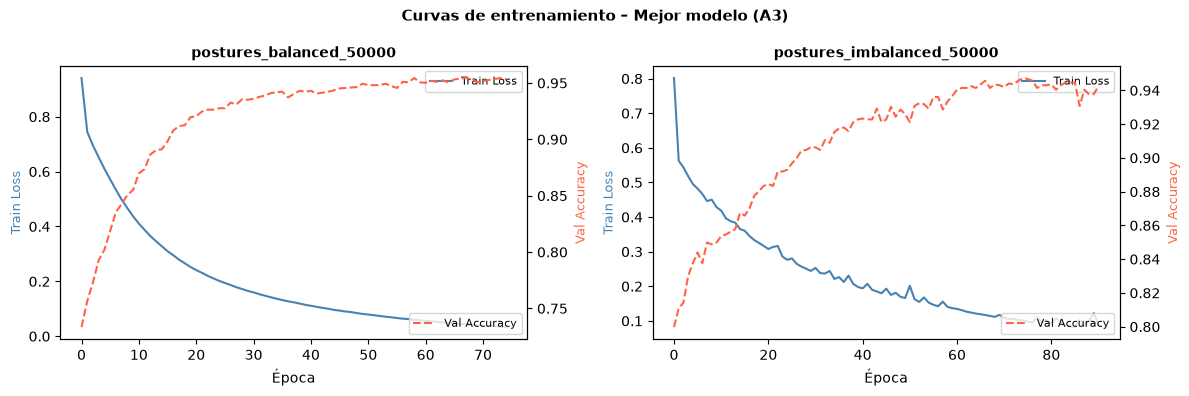

In [16]:
def plot_curvas(modelo_b, modelo_imb, nombre_b, nombre_imb):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
    for ax, modelo, nombre in zip(axes, [modelo_b, modelo_imb], [nombre_b, nombre_imb]):
        ax.plot(modelo.loss_curve_, color="steelblue", label="Train Loss")
 
        if hasattr(modelo, "validation_scores_") and modelo.validation_scores_:
            ax2 = ax.twinx()
            ax2.plot(modelo.validation_scores_, color="tomato",
                     linestyle="--", label="Val Accuracy")
            ax2.set_ylabel("Val Accuracy", color="tomato", fontsize=9)
            ax2.legend(loc="lower right", fontsize=8)
 
        ax.set_title(nombre, fontsize=10, fontweight="bold")
        ax.set_xlabel("Época")
        ax.set_ylabel("Train Loss", color="steelblue", fontsize=9)
        ax.legend(loc="upper right", fontsize=8)
 
    fig.suptitle("Curvas de entrenamiento – Mejor modelo (A3)", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()
 
plot_curvas(modelo_b, modelo_imb, nombre_b, nombre_imb)

### Análisis de las curvas:
* En BALANCED se observan curvas de Train Loss y Val Acc más estables, además de una convergencia del Train Loss en menos cantidad de épocas (75), mientras que Val Acc entre las épocas 30-40.

* En IMBALANCE las curvas son más inestables, Train Loss converge en la época 91 mientras que Val Acc lo hace cerca de la 70-80. Esto se puede deber a que, al tener clases con menos densidad de datos, el modelo tienda a hacer saltos muy abruptos en la actualización de sus pesos, lo que termina haciendo que el modelo tarde más en estabilizarse.


## Ítem 3)

* El dataset IMBALANCED tuvo el peor rendimiento (en base a su F1). El principal problema de que tuviera menor rendimiento debe ser por la cantidad de referencias que tiene el dataset de cada clase (ya que se usó la misma arquitectura A3 para ambos y aun así obtuvo peor resultado), por lo que la idea es que el modelo pueda adaptarse a esas clases con poca información para aprender.

* Idea de cómo mejorar modelo:
    * Mantener cantidad de capas ocultas, ya que no parece mejorar la eficiencia del modelo (visto en las arquitecturas A2 y A4)
    * Mantener valor de regularización. Lo más posible es que salgan afectadas las clases con más muestras.
    * Mantener función de activación Tangente Hiperbólica (Obtuvo mejores resultados que ReLU y Sigmoide)

    * Aumentar cantidad de neuronas por capa (512, 256), quizás así el modelo mejore al encontrar relaciones más complejas (ayudaría a todas las clases).
    * Disminuir batch-size (64), para que el modelo actualice sus pesos más veces por época. Lo que debería generar resultados más consistentes. 
    * Aumentar número máximo de épocas (200), dado que puede que el modelo tarde más en estabilizarse dado al nuevo batch-size.

    
    


In [17]:
def mejorar_arquitectura():
    return MLPClassifier(
            hidden_layer_sizes  = (512, 256),
            activation          = "tanh",
            learning_rate_init  = 0.001,
            batch_size          = 64,
            max_iter            = 200,
            alpha               = 0.0001,
            random_state        = SEED,
            early_stopping      = True,
            validation_fraction = 0.1,
            n_iter_no_change    = 15,
        )

In [18]:
X_imb_train, X_imb_val, X_imb_test, y_imb_train, y_imb_val, y_imb_test = split_data(X_imbalanced, y_imbalanced)

X_imb_train, X_imb_val, X_imb_test = scale_data(X_imb_train, X_imb_val, X_imb_test)

  Train: 18779 | Val: 4025 | Test: 4025


In [19]:
modelo_imb_mejorado = mejorar_arquitectura()
modelo_imb_mejorado.fit(X_imb_train, y_imb_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(512, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",64
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"n_iter_no_change n_iter_no_change: int, default=10Maximum number of epochs to not meet ``tol`` improvement.Only effective when solver='sgd' or 'adam'... versionadded:: 0.20",15
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is u

In [20]:
y_imb_pred_mejorado, metricas_imb_mejorado = evaluar_modelo(modelo_imb_mejorado, X_imb_test, y_imb_test, nombre_imb)

========= Evaluacion del dataset postures_imbalanced_50000 =========
  Accuracy  : 0.9468
  Precision : 0.9248  (macro)
  Recall    : 0.9135  (macro)
  F1        : 0.9190  (macro)

  Reporte por clase:
              precision    recall  f1-score   support

           1       0.99      0.97      0.98       389
           2       0.97      0.97      0.97      2071
           3       0.94      0.96      0.95       887
           4       0.88      0.86      0.87       531
           5       0.85      0.80      0.83       147

    accuracy                           0.95      4025
   macro avg       0.92      0.91      0.92      4025
weighted avg       0.95      0.95      0.95      4025



In [21]:
print("=================================================================================")
print(f" METRICA        IMBALANCED (A3)   IMBALANCED (MEJORADO)      DIFERENCIA")
print("=================================================================================")
for metrica in ["accuracy", "precision", "recall", "f1"]:
    print(f"  {metrica:<12} {metricas_imb[metrica]:>10.4f}  {metricas_imb_mejorado[metrica]:>18.4f} {(metricas_imb_mejorado[metrica]-metricas_imb[metrica]):>22.4f}")

 METRICA        IMBALANCED (A3)   IMBALANCED (MEJORADO)      DIFERENCIA
  accuracy         0.9299              0.9468                 0.0169
  precision        0.9150              0.9248                 0.0098
  recall           0.8811              0.9135                 0.0325
  f1               0.8965              0.9190                 0.0224


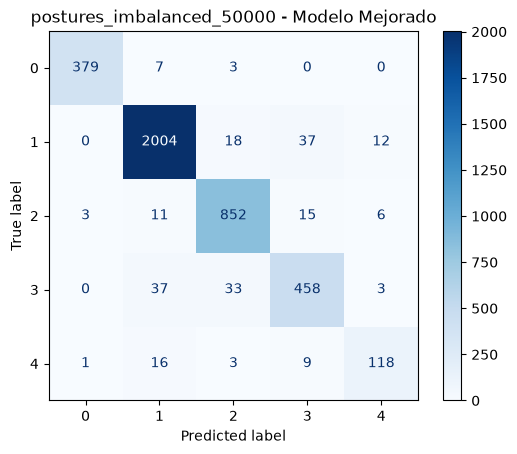

In [22]:
y_imb_pred_mejorado = modelo_imb_mejorado.predict(X_imb_test)

cm = confusion_matrix(y_imb_test, y_imb_pred_mejorado)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("postures_imbalanced_50000 - Modelo Mejorado")
plt.show()

### Análisis de la evaluación de la mejora propuesta

* Se observa una mejora en general de las métricas

* Accuracy aumenta un 2%
* Precision aumenta un 1%
* Recall aumenta un 3%
* F1 queda en 92%

* El modelo A3 antes acertaba el 97%, 96%, 94%, 81% y 72% de veces para cada clase respectivamente.
* El modelo mejorado acierta el 97%, 96%, 96%, 86% y 80% de veces para cada clase respectivamente.

En conclusión, la mejora propuesta si aumento las métricas del modelo, especialmente ayudo a las clases con menos muestras a ser más acertadas, como se ve en la matriz de confusión, las clases más beneficiadas fueron las que tenían menos datos, teniendo mejoras del 5% y 8% para la clase 4 y 5 respectivamente, mientras que para las demás no se obtuvo una mejora muy notable (~0%). Lo que demuestra que el modelo tenía menor rendimiento dadas estas clases con menor densidad de datos, las cuales se beneficiaron del aumento de neuronas por capa, haciendo que se reconozcan relaciones más complejas y además de la disminución del batch-size, el cual permitió que el modelo actualice de manera más recurrente sus pesos, haciendo que estos sean más precisos.
